<a href="https://colab.research.google.com/github/MaryamNourii/ECG-Signals/blob/Preprocessing/ECG_Denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip '/content/drive/MyDrive/ecg/mit-bih-arrhythmia-database-1.0.0.zip'

Archive:  /content/drive/MyDrive/ecg/mit-bih-arrhythmia-database-1.0.0.zip
  inflating: mit-bih-arrhythmia-database-1.0.0/100.atr  
  inflating: mit-bih-arrhythmia-database-1.0.0/100.dat  
  inflating: mit-bih-arrhythmia-database-1.0.0/100.hea  
  inflating: mit-bih-arrhythmia-database-1.0.0/100.xws  
  inflating: mit-bih-arrhythmia-database-1.0.0/101.atr  
  inflating: mit-bih-arrhythmia-database-1.0.0/101.dat  
  inflating: mit-bih-arrhythmia-database-1.0.0/101.hea  
  inflating: mit-bih-arrhythmia-database-1.0.0/101.xws  
  inflating: mit-bih-arrhythmia-database-1.0.0/102-0.atr  
  inflating: mit-bih-arrhythmia-database-1.0.0/102.atr  
  inflating: mit-bih-arrhythmia-database-1.0.0/102.dat  
  inflating: mit-bih-arrhythmia-database-1.0.0/102.hea  
  inflating: mit-bih-arrhythmia-database-1.0.0/102.xws  
  inflating: mit-bih-arrhythmia-database-1.0.0/103.atr  
  inflating: mit-bih-arrhythmia-database-1.0.0/103.dat  
  inflating: mit-bih-arrhythmia-database-1.0.0/103.hea  
  inflating

In [ ]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 3.3 MB/s eta 0:00:00


In [ ]:
!pip install matplotlib

In [ ]:
# import wfdb
import numpy as np
from matplotlib import pyplot as plt
import glob
from scipy import fftpack

In [ ]:
dctLbls = {
          'N': ['N', '.', 'L', 'R', 'j', 'e'],
          'S' : ['A', 'a', 'S', 'J'],
          'F' :['V', 'E'],
          'V' :['F'],
          'U' :['Q','/', 'p', 'f']
          }

In [ ]:
fName= '/content/mit-bih-arrhythmia-database-1.0.0/'
fNames = glob.glob(fName + '*.dat')
fNames[0]

'/content/mit-bih-arrhythmia-database-1.0.0/100.dat'

In [ ]:
fNames[0].split('.dat')

['/content/mit-bih-arrhythmia-database-1.0.0/100', '']

In [ ]:
data0N = []
data0S = []
data0F = []
data0V = []
data0U = []

for name in fNames:
  fN = name.split('.dat')[0]
  signals, fileds = wfdb.rdsamp(fN)
  annotation = wfdb.rdann(fN, 'atr')
  fs = annotation.fs
  pos = annotation.sample
  lbls = annotation.symbol

  for i in range(1,len(pos)-1):
    indx = list(range(pos[i]-20,pos[i]+40))
    qrs0 = signals[indx,0]
    stype = lbls[i]

    if stype in dctLbls['N']:
      data0N.append(qrs0)
    elif stype in dctLbls['S']:
      data0S.append(qrs0)
    elif stype in dctLbls['F']:
      data0F.append(qrs0)
    elif stype in dctLbls['V']:
      data0V.append(qrs0)
    elif stype in dctLbls['U']:
      data0U.append(qrs0)


data0N = np.array(data0N, dtype = np.float64)
data0S = np.array(data0S, dtype = np.float64)
data0F = np.array(data0F, dtype = np.float64)
data0V = np.array(data0V, dtype = np.float64)
data0U = np.array(data0U, dtype = np.float64)

len(data0N), len(data0S), len(data0F), len(data0V), len(data0U)

(90589, 2779, 7236, 803, 8039)

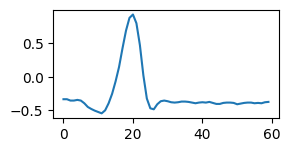

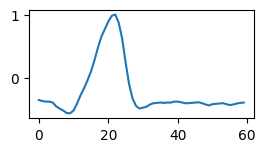

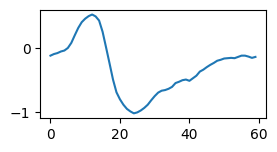

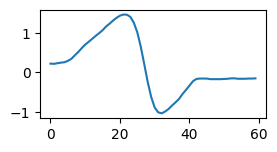

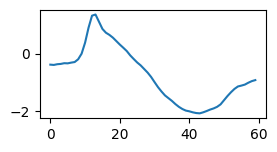

In [ ]:
dataN = np.array(data0N[9:10], dtype = np.float64)
dataS = np.array(data0S[9:10], dtype = np.float64)
dataF = np.array(data0F[9:10], dtype = np.float64)
dataV = np.array(data0V[9:10], dtype = np.float64)
dataU = np.array(data0U[9:10], dtype = np.float64)

plt.subplot(3,2,1)
plt.plot(dataN.T)
plt.show()

plt.subplot(3,2,2)
plt.plot(dataS.T)
plt.show()

plt.subplot(3,2,3)
plt.plot(dataF.T)
plt.show()

plt.subplot(3,2,4)
plt.plot(dataV.T)
plt.show()

plt.subplot(3,2,5)
plt.plot(dataU.T)
plt.show()

**تمرین 1**

In [ ]:
n = 1000
fmax =  int(fs/2)

fftN = fftpack.fft(dataN, n, axis = 1)
fftS = fftpack.fft(dataS, n, axis = 1)
fftF = fftpack.fft(dataF, n, axis = 1)
fftV = fftpack.fft(dataV, n, axis = 1)
fftU = fftpack.fft(dataU, n, axis = 1)

impN = np.abs(fftN)
impS = np.abs(fftS)
impF = np.abs(fftF)
impV = np.abs(fftV)
impU = np.abs(fftU)


rf = np.linspace(0, fmax, 1000)

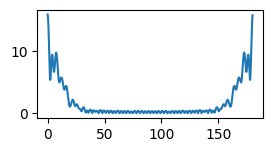

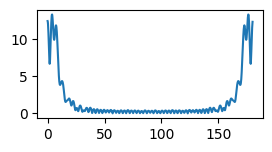

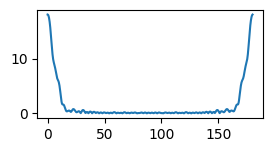

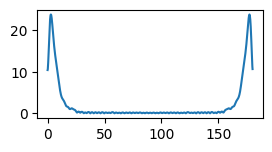

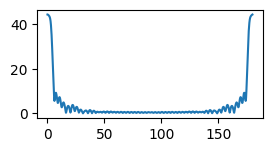

In [ ]:
plt.subplot(3,2,1)
plt.plot(rf, impN.T)
plt.show()

plt.subplot(3,2,2)
plt.plot(rf, impS.T)
plt.show()

plt.subplot(3,2,3)
plt.plot(rf, impF.T)
plt.show()

plt.subplot(3,2,4)
plt.plot(rf, impV.T)
plt.show()

plt.subplot(3,2,5)
plt.plot(rf, impU.T)
plt.show()

**تمرین 2**

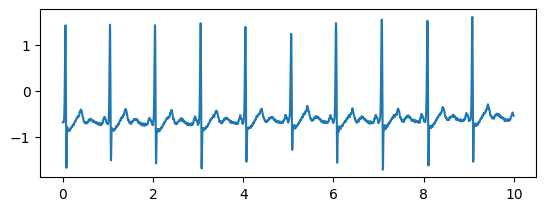

In [ ]:
sig = np.array(signals[:,0], dtype = np.float64)


L= sig.shape[0]
T= L/fs
t= np.linspace(0,T,L)

n= 10*fs

plt.subplot(2,1,1)
plt.plot(t[:n],sig[:n])
plt.show()


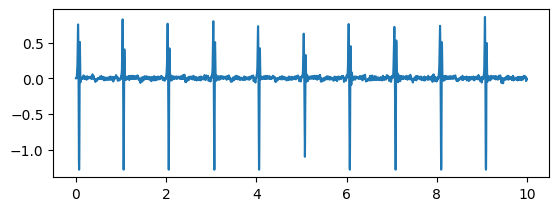

In [ ]:
# k1
k1 = [-1.0, 0.0, 1.0]
ks = 3
n = int(ks/2)
sig_pad = np.pad(sig, pad_width = 1, mode = 'edge')

sig_new = np.zeros_like(sig)

for i in range(n, sig_pad.shape[0]-n):
  temp = sig_pad[i-n:i+n+1]
  temp = np.multiply(temp, k1)
  stemp = np.sum(temp)
  sig_new[i-n] = stemp



L= sig_new.shape[0]
T= L/fs
t= np.linspace(0,T,L)

n= 10*fs

plt.subplot(2,1,1)
plt.plot(t[:n],sig_new[:n])
plt.show()


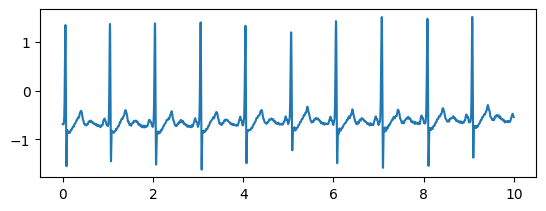

In [ ]:
# k2
k2 = [1/3, 1/3, 1/3]

ks = 3
n = int(ks/2)
sig_pad = np.pad(sig, pad_width = 1, mode = 'edge')

sig_new = np.zeros_like(sig)

for i in range(n, sig_pad.shape[0]-n):
  temp = sig_pad[i-n:i+n+1]
  temp = np.multiply(temp, k2)
  stemp = np.sum(temp)
  sig_new[i-n] = stemp



L= sig_new.shape[0]
T= L/fs
t= np.linspace(0,T,L)

n= 10*fs

plt.subplot(2,1,1)
plt.plot(t[:n],sig_new[:n])
plt.show()


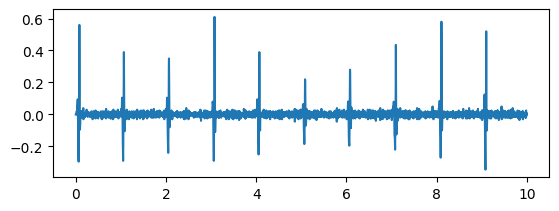

In [ ]:
# k3
k3 = [1, -2, 1]

ks = 3
n = int(ks/2)
sig_pad = np.pad(sig, pad_width = 1, mode = 'edge')

sig_new = np.zeros_like(sig)

for i in range(n, sig_pad.shape[0]-n):
  temp = sig_pad[i-n:i+n+1]
  temp = np.multiply(temp, k3)
  stemp = np.sum(temp)
  sig_new[i-n] = stemp



L= sig_new.shape[0]
T= L/fs
t= np.linspace(0,T,L)

n= 10*fs

plt.subplot(2,1,1)
plt.plot(t[:n],sig_new[:n])
plt.show()


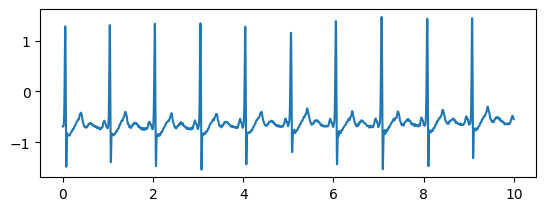

In [ ]:
#k4
k4 = [0.1, 0.2, 0.4, 0.2, 0.1]
ks = 5
n = int(ks/2)
sig_pad = np.pad(sig, pad_width = 1, mode = 'edge')

sig_new = np.zeros_like(sig)

for i in range(n, sig_pad.shape[0]-n):
  temp = sig_pad[i-n:i+n+1]
  temp = np.multiply(temp, k4)
  stemp = np.sum(temp)
  sig_new[i-n] = stemp



L= sig_new.shape[0]
T= L/fs
t= np.linspace(0,T,L)

n= 10*fs

plt.subplot(2,1,1)
plt.plot(t[:n],sig_new[:n])
plt.show()

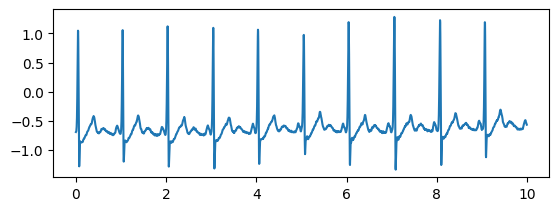

In [ ]:
#k5
k5 = [1/16, 1/16, 1/16, 1/16, 8/16, 1/16, 1/16, 1/16, 1/16]
ks = 9
n = int(ks/2)
sig_pad = np.pad(sig, pad_width = 1, mode = 'edge')

sig_new = np.zeros_like(sig)

for i in range(n, sig_pad.shape[0]-n):
  temp = sig_pad[i-n:i+n+1]
  temp = np.multiply(temp, k5)
  stemp = np.sum(temp)
  sig_new[i-n] = stemp



L= sig_new.shape[0]
T= L/fs
t= np.linspace(0,T,L)

n= 10*fs

plt.subplot(2,1,1)
plt.plot(t[:n],sig_new[:n])
plt.show()


**تمرین 3**

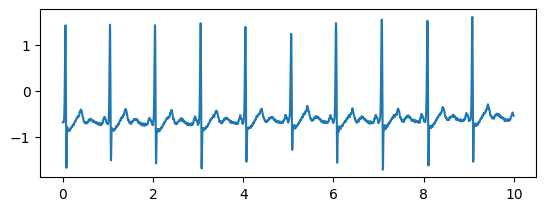

In [ ]:
sig = np.array(signals[:,0], dtype = np.float64)

L= sig.shape[0]
T= L/fs
t= np.linspace(0,T,L)

n= 10*fs

plt.subplot(2,1,1)
plt.plot(t[:n],sig[:n])
plt.show()

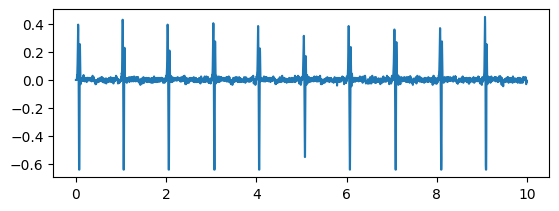

In [ ]:
########################## Reverse Kernel
k = [-1, 1]
ks = 2
n = int(ks/2)
sig_pad = np.pad(sig, pad_width = 1, mode = 'edge')

sig_new = np.zeros_like(sig)

for i in range(n, sig_pad.shape[0]-n):
  temp = sig_pad[i-n:i+n]
  temp = np.multiply(temp, k)
  stemp = np.sum(temp)
  sig_new[i-n] = stemp



L= sig_new.shape[0]
T= L/fs
t= np.linspace(0,T,L)

n= 10*fs

plt.subplot(2,1,1)
plt.plot(t[:n],sig_new[:n])
plt.show()

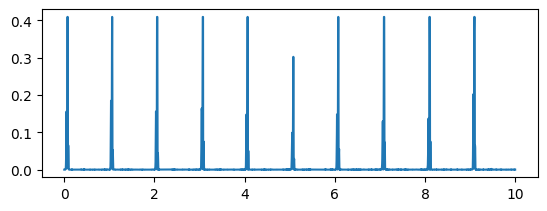

In [ ]:
# New_Signal ** 2
sig_new = sig_new ** 2
L= sig_new.shape[0]
T= L/fs
t= np.linspace(0,T,L)

n= 10*fs

plt.subplot(2,1,1)
plt.plot(t[:n],sig_new[:n])
plt.show()

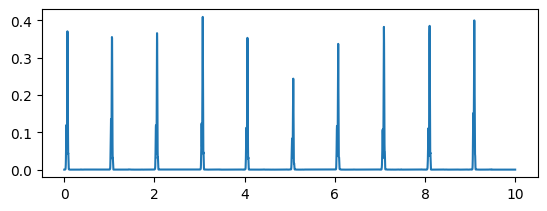

In [ ]:
# Avg kernel
k = [1/4, 1/4, 1/4, 1/4]
ks = 4
n = int(ks/2)
sig_pad = np.pad(sig_new, pad_width = 1, mode = 'edge')

sig_new1 = np.zeros_like(sig)

for i in range(n, sig_pad.shape[0]-n):
  temp = sig_pad[i-n:i+n]
  temp = np.multiply(temp, k)
  stemp = np.sum(temp)
  sig_new1[i-n] = stemp



L= sig_new1.shape[0]
T= L/fs
t= np.linspace(0,T,L)

n= 10*fs

plt.subplot(2,1,1)
plt.plot(t[:n],sig_new1[:n])
plt.show()

**تمرین 4**

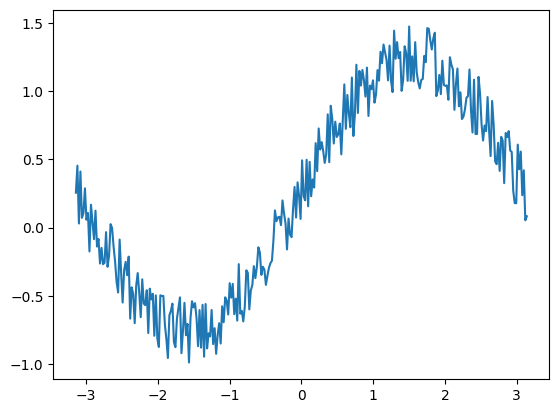

In [ ]:
fs=300
rng= np.random.default_rng(1)
x= np.linspace(-np.pi, np.pi,300)
sig= np.sin(x)+rng.random(x.shape)*0.5

plt.plot(x,sig)
plt.show()

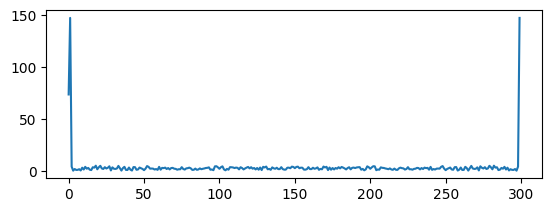

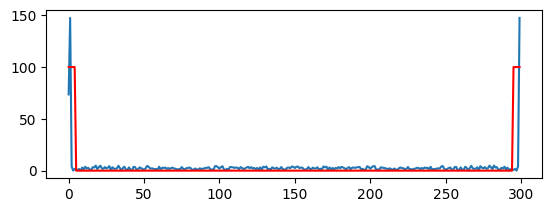

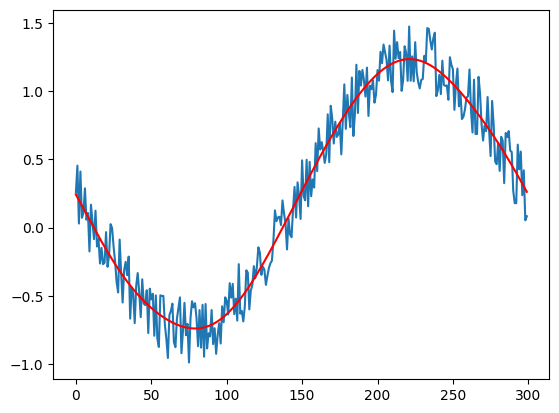

In [ ]:
#Low Pass

fx= fftpack.fft(sig,axis=0)
rf= np.linspace(0,fs/2,150)

plt.subplot(2,1,1)
plt.plot(np.abs(fx))
plt.show()

rf = np.concatenate((rf,rf[::-1]),axis=0)
H = np.array(rf<5,dtype=np.float64)
fx_2= np.multiply(fx,H)

plt.subplot(2,1,1)
plt.plot(np.abs(fx))
plt.plot(H*100,'r')
plt.show()

sig_new= np.real(fftpack.ifft(fx_2))

plt.plot(sig)
plt.plot(sig_new,'r')
plt.show()



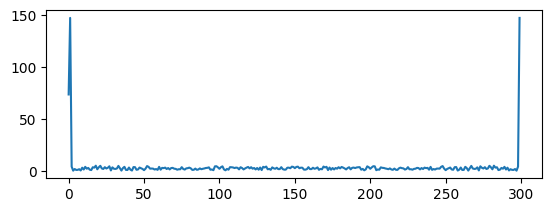

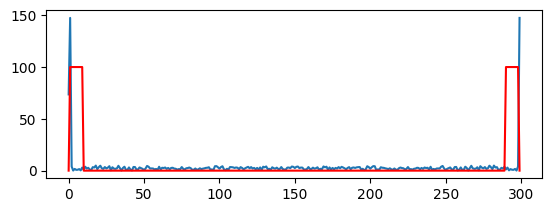

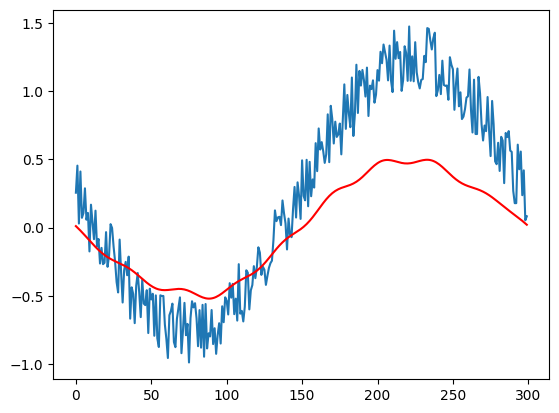

In [ ]:
#Band Pass

fx= fftpack.fft(sig,axis=0)
rf= np.linspace(0,fs/2,150)

plt.subplot(2,1,1)
plt.plot(np.abs(fx))
plt.show()


rf = np.concatenate((rf,rf[::-1]),axis=0)
H = np.array((rf>0.5) & (rf<10),dtype=np.float64)
fx_2= np.multiply(fx,H)

plt.subplot(2,1,1)
plt.plot(np.abs(fx))
plt.plot(H*100,'r')
plt.show()

sig_new= np.real(fftpack.ifft(fx_2))

plt.plot(sig)
plt.plot(sig_new,'r')
plt.show()



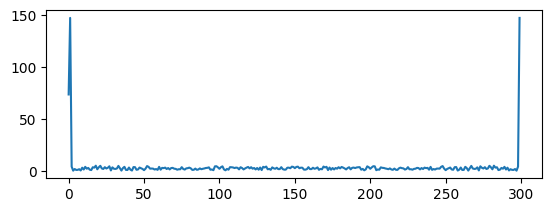

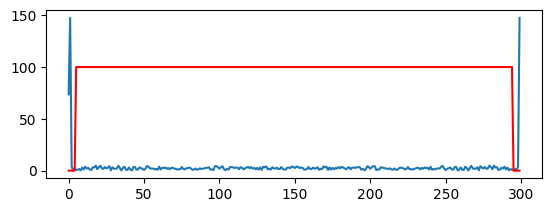

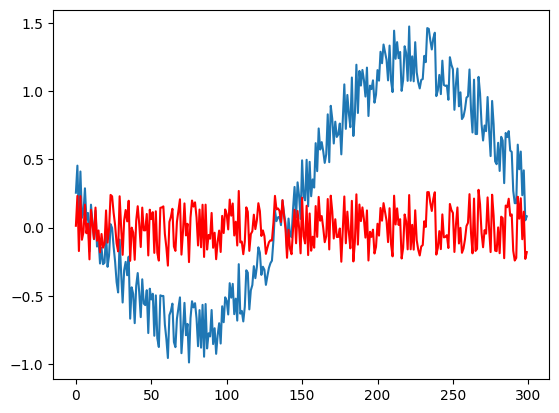

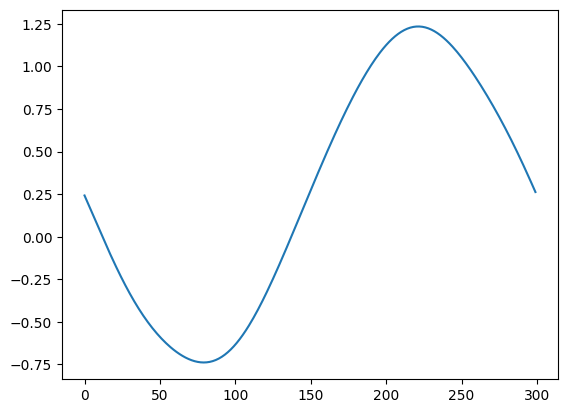

In [ ]:
#High Pass
fx= fftpack.fft(sig,axis=0)
rf= np.linspace(0,fs/2,150)

plt.subplot(2,1,1)
plt.plot(np.abs(fx))
plt.show()


rf = np.concatenate((rf,rf[::-1]),axis=0)
H = np.array(rf>5,dtype=np.float64)
fx_2= np.multiply(fx,H)

plt.subplot(2,1,1)
plt.plot(np.abs(fx))
plt.plot(H*100,'r')
plt.show()

sig_new= np.real(fftpack.ifft(fx_2))

plt.plot(sig)
plt.plot(sig_new,'r')
plt.show()


sig_new2 = sig - sig_new
plt.plot(sig_new2)
plt.show()

# Since the signal resulting from Fourier inversion is a noise signal, by removing it from the original signal, a noise-free signal is obtained